<a href="https://colab.research.google.com/github/Mahendra-69/CSL701-CS09_Machine-Learning-Lab/blob/main/Expriments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Mahendra R. Choudhari

Batch :CS1


Roll Number :CS09



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Load dataset
df = pd.read_csv('/content/brca.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (569, 32)

First 5 rows:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [7]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Dataset dimensions
print("\nDataset Dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Diagnosis class distribution
print("\nDiagnosis Class Distribution:")
print(df['y'].value_counts())

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Summary Statistics:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Dataset Dimensions:
Rows: 569
Columns: 32

Diagnosis Class Distribution:
y
B    357
M    212
Name: count, dtype: int64


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [8]:
# Separate features and target
X = df.drop(columns=['Unnamed: 0', 'y'])
y = df['y']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original feature shape: (569, 30)
Scaled feature shape: (569, 30)

First 5 scaled rows:
[[-1.66799191e-01 -1.14716230e+00 -1.85727988e-01 -2.51956501e-01
   1.01746571e-01 -4.36850252e-01 -2.78209570e-01 -2.86092890e-02
   2.67911231e-01 -7.28309656e-01 -4.88225261e-01 -7.76998992e-01
  -4.00014052e-01 -3.69124423e-01  4.73692902e-01 -6.07974170e-01
  -2.66042547e-01  2.19609651e-01 -8.98764242e-02 -5.65449394e-01
  -2.40047958e-01 -1.04500496e+00 -2.25217058e-01 -2.97760754e-01
   5.09873049e-01 -4.89605212e-01 -1.59222529e-01  2.16122925e-01
   1.23346531e-01 -6.29291894e-01]
 [-2.97445722e-01 -8.33008236e-01 -2.61106055e-01 -3.83638452e-01
   7.92763012e-01  4.29421872e-01 -5.41361764e-01 -4.59626734e-01
   5.67288590e-01  7.53086584e-01 -7.93925350e-01 -8.51205657e-01
  -7.34159715e-01 -5.64719621e-01 -9.81366092e-01 -3.63177987e-01
  -4.94494435e-01 -8.60706722e-01 -4.55533505e-01 -5.18167976e-01
  -3.66368301e-01 -8.44707093e-01 -3.32743935e-01 -4.39624310e-01
  -5.12263607e-02  

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [9]:
# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric='euclidean'))

print("Distance Matrix Shape:", distance_matrix.shape)

print("\nFirst 5 × 5 Distance Matrix:")
print(distance_matrix[:5, :5])

# Create weighted complete graph
G = nx.Graph()

for i in range(len(X_scaled)):
    G.add_node(i)

for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(i, j, weight=distance_matrix[i, j])

print("\nGraph created successfully!")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)

First 5 × 5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]

Graph created successfully!
Number of nodes: 569
Number of edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [14]:
# Compute the Minimum Spanning Tree (MST)
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert the sparse MST to a dense matrix for easier edge extraction
mst_dense = mst_sparse.toarray()

# Extract MST edges and weights
mst_edges = []
for i in range(len(mst_dense)):
    for j in range(i + 1, len(mst_dense)): # Iterate only the upper triangle
        if mst_dense[i, j] != 0:
            mst_edges.append((i, j, mst_dense[i, j]))

print("MST computed successfully!")
print("Number of MST edges:", len(mst_edges))


MST computed successfully!
Number of MST edges: 568


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [15]:
# Sort MST edges by weight in descending order
mst_edges_sorted = sorted(mst_edges, key=lambda x: x[2], reverse=True)

# For K=2 clusters, remove the single largest edge
if len(mst_edges_sorted) > 0:
    edge_to_cut = mst_edges_sorted[0]
    print(f"Edge to cut (largest weight): {edge_to_cut}")
else:
    print("No MST edges to cut.")
    edge_to_cut = None

# Create a graph from the MST edges (excluding the cut edge)
clustered_graph = nx.Graph()
# Add all original nodes first to ensure all data points are represented
for i in range(len(X_scaled)):
    clustered_graph.add_node(i)

if edge_to_cut:
    for u, v, weight in mst_edges:
        # Only add edges that are not the one to be cut
        # Check both (u,v) and (v,u) because networkx graphs are undirected
        if not ((u == edge_to_cut[0] and v == edge_to_cut[1]) or \
                (u == edge_to_cut[1] and v == edge_to_cut[0])):
            clustered_graph.add_edge(u, v, weight=weight)
else: # If no edge to cut (e.g., only one node), add all mst_edges
    for u, v, weight in mst_edges:
        clustered_graph.add_edge(u, v, weight=weight)


# Find connected components, which represent the clusters
clusters = list(nx.connected_components(clustered_graph))
print(f"Number of clusters formed: {len(clusters)}")

# Assign cluster labels to each data point
cluster_labels = np.zeros(len(X_scaled), dtype=int)
for i, cluster in enumerate(clusters):
    for node_idx in cluster:
        cluster_labels[node_idx] = i

print("First 10 cluster labels:", cluster_labels[:10])


Edge to cut (largest weight): (544, 553, np.float64(12.299945385815649))
Number of clusters formed: 2
First 10 cluster labels: [0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [16]:
# Convert true labels 'y' to numerical format (0 or 1)
# Assuming 'B' for Benign and 'M' for Malignant
true_labels_numeric = y.map({'B': 0, 'M': 1}).values

# Evaluate clustering performance
silhouette = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(true_labels_numeric, cluster_labels)
nmi = normalized_mutual_info_score(true_labels_numeric, cluster_labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

/tmp/ipykernel_2996/2429592020.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_clusters))


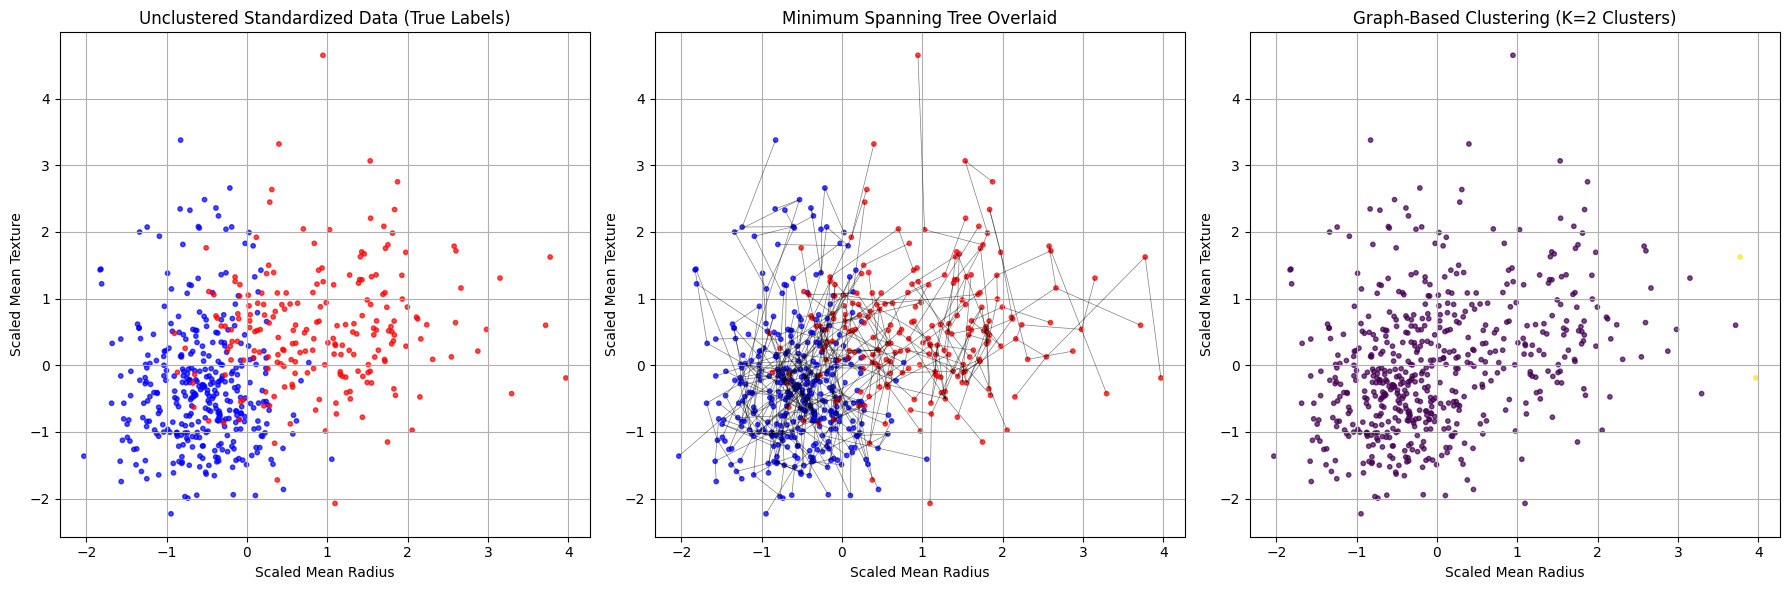

In [17]:
# Select two representative features for visualization
# 'x.radius_mean' is at index 0 and 'x.texture_mean' is at index 1 in X (and X_scaled)
feature1_idx = X.columns.get_loc('x.radius_mean')
feature2_idx = X.columns.get_loc('x.texture_mean')

# Using X_scaled for plotting as the distances were computed on scaled features
x_plot = X_scaled[:, feature1_idx]
y_plot = X_scaled[:, feature2_idx]

# Get the true labels for coloring the plots
color_map_true = y.map({'B': 'blue', 'M': 'red'})

plt.figure(figsize=(18, 6))

# Plot 1: Unclustered standardized data points
plt.subplot(1, 3, 1)
plt.scatter(x_plot, y_plot, c=color_map_true, s=10, alpha=0.7)
plt.title('Unclustered Standardized Data (True Labels)')
plt.xlabel('Scaled Mean Radius')
plt.ylabel('Scaled Mean Texture')
plt.grid(True)


# Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data
plt.subplot(1, 3, 2)
plt.scatter(x_plot, y_plot, c=color_map_true, s=10, alpha=0.7)
for u, v, weight in mst_edges:
    plt.plot([x_plot[u], x_plot[v]], [y_plot[u], y_plot[v]], 'k-', linewidth=0.5, alpha=0.5)
plt.title('Minimum Spanning Tree Overlaid')
plt.xlabel('Scaled Mean Radius')
plt.ylabel('Scaled Mean Texture')
plt.grid(True)

# Plot 3: Final clusters formed after cutting the K-1 largest edge(s)
# Use cluster_labels for coloring
unique_clusters = np.unique(cluster_labels)
# Generate distinct colors for each cluster
colors = plt.colormaps['viridis'](np.linspace(0, 1, len(unique_clusters)))
cluster_colors = [colors[i] for i in cluster_labels]

plt.subplot(1, 3, 3)
plt.scatter(x_plot, y_plot, c=cluster_colors, s=10, alpha=0.7)
plt.title(f'Graph-Based Clustering (K={len(unique_clusters)} Clusters)')
plt.xlabel('Scaled Mean Radius')
plt.ylabel('Scaled Mean Texture')
plt.grid(True)

plt.tight_layout()
plt.show()


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.